In [100]:
import pandas as pd
import matplotlib.pyplot as plt

# UCI Auto MPG 
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
columns = [
    'mpg', 'cylinders', 'displacement', 'horsepower',
    'weight', 'acceleration', 'model_year', 'origin','car_name'
]

df = pd.read_csv(
    url,
    delim_whitespace=True,
    names=columns,
    na_values='?'
)

# clean the data
df = df.dropna()
print(df)


C:\Users\Biao Wang\AppData\Local\Temp\ipykernel_4920\187595932.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


      mpg  cylinders  displacement  horsepower  weight  acceleration  \
0    18.0          8         307.0       130.0  3504.0          12.0   
1    15.0          8         350.0       165.0  3693.0          11.5   
2    18.0          8         318.0       150.0  3436.0          11.0   
3    16.0          8         304.0       150.0  3433.0          12.0   
4    17.0          8         302.0       140.0  3449.0          10.5   
..    ...        ...           ...         ...     ...           ...   
393  27.0          4         140.0        86.0  2790.0          15.6   
394  44.0          4          97.0        52.0  2130.0          24.6   
395  32.0          4         135.0        84.0  2295.0          11.6   
396  28.0          4         120.0        79.0  2625.0          18.6   
397  31.0          4         119.0        82.0  2720.0          19.4   

     model_year  origin                   car_name  
0            70       1  chevrolet chevelle malibu  
1            70       1      

In [101]:
print(df[['horsepower', 'displacement']].describe())

       horsepower  displacement
count  392.000000    392.000000
mean   104.469388    194.411990
std     38.491160    104.644004
min     46.000000     68.000000
25%     75.000000    105.000000
50%     93.500000    151.000000
75%    126.000000    275.750000
max    230.000000    455.000000


### Data preparation ###
We split the data set according to:
- train : validation : test = 6:2:2

In [102]:
from sklearn.model_selection import train_test_split

# Separate features and target (keep ALL feature columns)
features_temp = df.drop(columns=['mpg'])
labels = df['mpg']

# First split: training + validation vs test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    features_temp,
    labels,
    test_size=0.2,
    random_state=42
)

# Second split: training vs validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,   # 0.25 of 0.8 = 0.2
    random_state=42
)

# Verify split sizes
print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)


Training set shape: (234, 8)
Validation set shape: (79, 8)
Test set shape: (79, 8)


In [103]:
print(X_train[['horsepower', 'displacement']].describe())


       horsepower  displacement
count  234.000000    234.000000
mean   104.508547    193.884615
std     38.697267    106.089967
min     48.000000     70.000000
25%     75.000000     98.000000
50%     94.500000    151.000000
75%    129.000000    302.000000
max    225.000000    455.000000


### Correlation analysis ###

In [104]:
import pandas as pd

# Combine training features and target into a single DataFrame
train_df = X_train.copy()
train_df['mpg'] = y_train

# Keep only numerical columns for correlation analysis
# (non-numeric columns such as car names cannot be used in Pearson correlation)
train_df_numeric = train_df.select_dtypes(include='number')

# Compute Pearson correlation matrix using training data only
corr_matrix = train_df_numeric.corr()

# Display the full correlation matrix
print(corr_matrix)

# Extract correlations between MPG and all numerical features
mpg_corr = corr_matrix['mpg'].drop('mpg')  # Remove self-correlation

# Rank features by the absolute value of correlation strength
mpg_corr = mpg_corr.reindex(
    mpg_corr.abs().sort_values(ascending=False).index
)

# Display feature–MPG correlations ranked by strength
print("\nCorrelation with MPG (Training Set Only):")
print(mpg_corr)


              cylinders  displacement  horsepower    weight  acceleration  \
cylinders      1.000000      0.956421    0.848290  0.898786     -0.504044   
displacement   0.956421      1.000000    0.900440  0.937842     -0.552704   
horsepower     0.848290      0.900440    1.000000  0.883385     -0.686687   
weight         0.898786      0.937842    0.883385  1.000000     -0.435045   
acceleration  -0.504044     -0.552704   -0.686687 -0.435045      1.000000   
model_year    -0.410572     -0.427497   -0.492789 -0.374405      0.328586   
origin        -0.564908     -0.608446   -0.467528 -0.582472      0.236640   
mpg           -0.783048     -0.816445   -0.801302 -0.842506      0.436971   

              model_year    origin       mpg  
cylinders      -0.410572 -0.564908 -0.783048  
displacement   -0.427497 -0.608446 -0.816445  
horsepower     -0.492789 -0.467528 -0.801302  
weight         -0.374405 -0.582472 -0.842506  
acceleration    0.328586  0.236640  0.436971  
model_year      1.000000

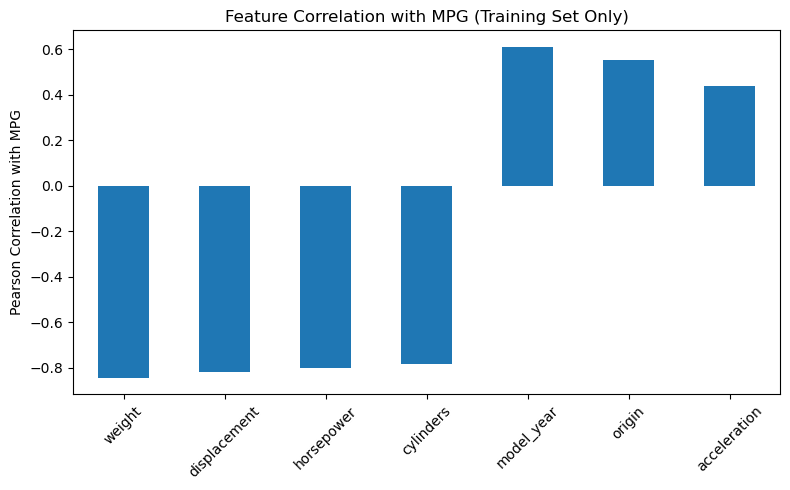

In [105]:
import matplotlib.pyplot as plt

# Combine training features and target into a single DataFrame
train_df = X_train.copy()
train_df['mpg'] = y_train

# Keep only numerical columns for correlation analysis
train_df_numeric = train_df.select_dtypes(include='number')

# Compute Pearson correlation matrix using training data only
corr_matrix = train_df_numeric.corr()

# Extract correlations between MPG and all numerical features
mpg_corr = corr_matrix['mpg'].drop('mpg')

# Sort features by absolute correlation strength
mpg_corr_sorted = mpg_corr.reindex(
    mpg_corr.abs().sort_values(ascending=False).index
)

# Plot correlation bar chart
plt.figure(figsize=(8, 5))
mpg_corr_sorted.plot(kind='bar')
plt.ylabel("Pearson Correlation with MPG")
plt.title("Feature Correlation with MPG (Training Set Only)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


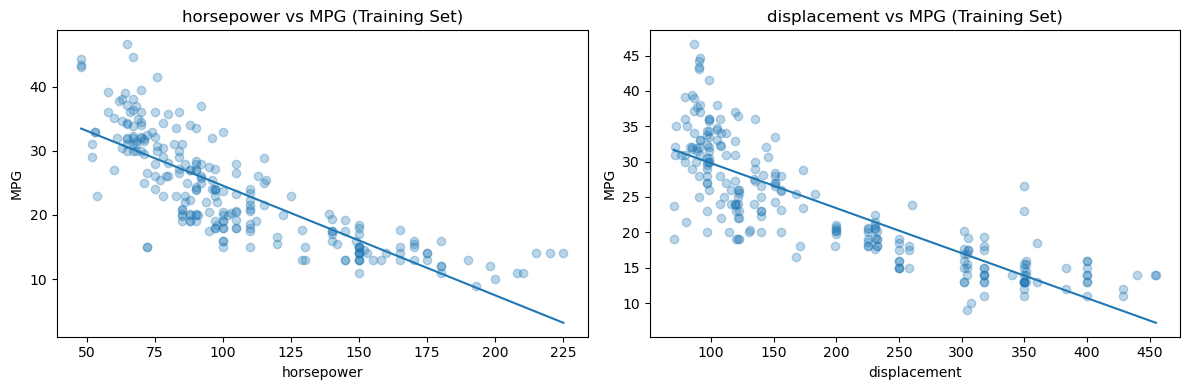

In [106]:
import matplotlib.pyplot as plt
import numpy as np

# Selected features after correlation analysis
selected_features = ['horsepower', 'displacement']
# I didn't choose cylinder since the cylinder value is not continuous

plt.figure(figsize=(12, 4))

for i, feature in enumerate(selected_features):
    plt.subplot(1, 2, i + 1)

    # Scatter plot using training data only
    plt.scatter(X_train[feature], y_train, alpha=0.3)

    # Fit and plot a linear trend line (for visualization only)
    z = np.polyfit(X_train[feature], y_train, 1)
    p = np.poly1d(z)
    x_sorted = np.sort(X_train[feature])
    plt.plot(x_sorted, p(x_sorted))

    plt.xlabel(feature)
    plt.ylabel("MPG")
    plt.title(f"{feature} vs MPG (Training Set)")

plt.tight_layout()
plt.show()


In [107]:
# Make some functions:
def trapezoidal_membership_function(domain, a, b, c, d):
    y = np.zeros_like(domain, dtype=float)
    
    # rising edge
    idx = (a < domain) & (domain < b)
    y[idx] = (domain[idx] - a) / (b - a)

    # top
    idx = (b <= domain) & (domain <= c)
    y[idx] = 1.0

    # falling edge
    idx = (c < domain) & (domain < d)
    y[idx] = (d - domain[idx]) / (d - c)

    return y


def gauss_membership_func(x, c, sigma):
    return np.exp(-0.5 * ((x - c) / sigma) ** 2)

def interp_membership(domain, mf_values, x):
    """
    Equivalent to skfuzzy.interp_membership
    domain: e.g. np.linspace(...)
    mf_values: membership values on that domain
    x: crisp input
    """
    return np.interp(x, domain, mf_values)

def centroid_defuzzification(domain, aggregated_mf):
    """
    Compute centroid defuzzification (discrete version).

    domain: np.ndarray
        The universe of discourse (e.g., domain_difficulty)
    aggregated_mf: np.ndarray
        Aggregated membership values over the domain

    returns: float
        Crisp output (centroid)
    """
    numerator = np.sum(domain * aggregated_mf)
    denominator = np.sum(aggregated_mf)

    if denominator == 0:
        # no rule fired → fallback (should rarely happen)
        return np.mean(domain)

    return numerator / denominator



### We start to set the membership functions for the 2 features ###

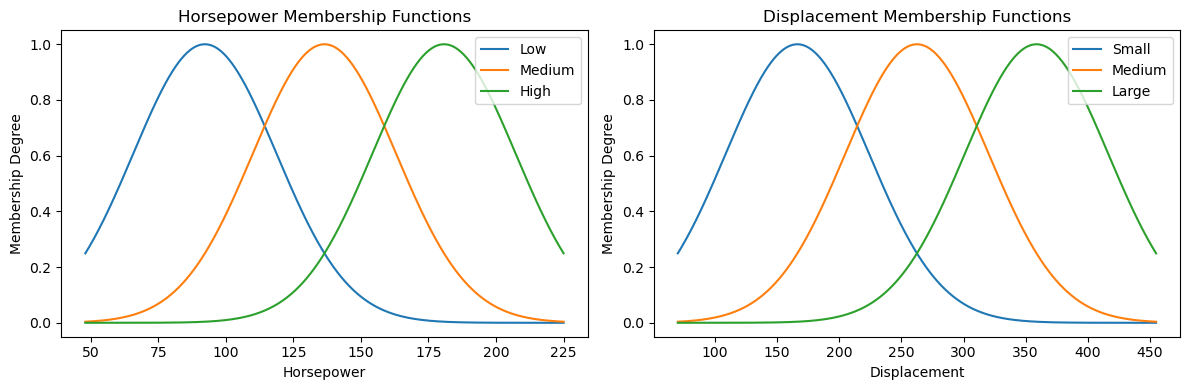

In [108]:
import numpy as np

# Define domains using training data only
hp_min, hp_max = X_train['horsepower'].min(), X_train['horsepower'].max()
disp_min, disp_max = X_train['displacement'].min(), X_train['displacement'].max()

domain_horsepower = np.linspace(hp_min, hp_max, 500)
domain_displacement = np.linspace(disp_min, disp_max, 500)

# # Horsepower membership functions
# hp_low = trapezoidal_membership_function(
#     domain_horsepower,
#     a=hp_min,
#     b=hp_min,
#     c=hp_min + 0.3 * (hp_max - hp_min),
#     d=hp_min + 0.5 * (hp_max - hp_min)
# )

# hp_medium = trapezoidal_membership_function(
#     domain_horsepower,
#     a=hp_min + 0.3 * (hp_max - hp_min),
#     b=hp_min + 0.45 * (hp_max - hp_min),
#     c=hp_min + 0.55 * (hp_max - hp_min),
#     d=hp_min + 0.7 * (hp_max - hp_min)
# )

# hp_high = trapezoidal_membership_function(
#     domain_horsepower,
#     a=hp_min + 0.5 * (hp_max - hp_min),
#     b=hp_min + 0.7 * (hp_max - hp_min),
#     c=hp_max,
#     d=hp_max
# )

# # Displacement membership functions
# disp_small = trapezoidal_membership_function(
#     domain_displacement,
#     a=disp_min,
#     b=disp_min,
#     c=disp_min + 0.3 * (disp_max - disp_min),
#     d=disp_min + 0.5 * (disp_max - disp_min)
# )

# disp_medium = trapezoidal_membership_function(
#     domain_displacement,
#     a=disp_min + 0.3 * (disp_max - disp_min),
#     b=disp_min + 0.45 * (disp_max - disp_min),
#     c=disp_min + 0.55 * (disp_max - disp_min),
#     d=disp_min + 0.7 * (disp_max - disp_min)
# )

# disp_large = trapezoidal_membership_function(
#     domain_displacement,
#     a=disp_min + 0.5 * (disp_max - disp_min),
#     b=disp_min + 0.7 * (disp_max - disp_min),
#     c=disp_max,
#     d=disp_max
# )

# Gaussian MF parameters (based on training data)
hp_range = hp_max - hp_min

hp_low = gauss_membership_func(
    domain_horsepower,
    c=hp_min + 0.25 * hp_range,
    sigma=0.15 * hp_range
)

hp_medium = gauss_membership_func(
    domain_horsepower,
    c=hp_min + 0.50 * hp_range,
    sigma=0.15 * hp_range
)

hp_high = gauss_membership_func(
    domain_horsepower,
    c=hp_min + 0.75 * hp_range,
    sigma=0.15 * hp_range
)

disp_range = disp_max - disp_min

disp_small = gauss_membership_func(
    domain_displacement,
    c=disp_min + 0.25 * disp_range,
    sigma=0.15 * disp_range
)

disp_medium = gauss_membership_func(
    domain_displacement,
    c=disp_min + 0.50 * disp_range,
    sigma=0.15 * disp_range
)

disp_large = gauss_membership_func(
    domain_displacement,
    c=disp_min + 0.75 * disp_range,
    sigma=0.15 * disp_range
)



import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Horsepower MFs
plt.subplot(1, 2, 1)
plt.plot(domain_horsepower, hp_low, label='Low')
plt.plot(domain_horsepower, hp_medium, label='Medium')
plt.plot(domain_horsepower, hp_high, label='High')
plt.title("Horsepower Membership Functions")
plt.xlabel("Horsepower")
plt.ylabel("Membership Degree")
plt.legend()

# Displacement MFs
plt.subplot(1, 2, 2)
plt.plot(domain_displacement, disp_small, label='Small')
plt.plot(domain_displacement, disp_medium, label='Medium')
plt.plot(domain_displacement, disp_large, label='Large')
plt.title("Displacement Membership Functions")
plt.xlabel("Displacement")
plt.ylabel("Membership Degree")
plt.legend()

plt.tight_layout()
plt.show()





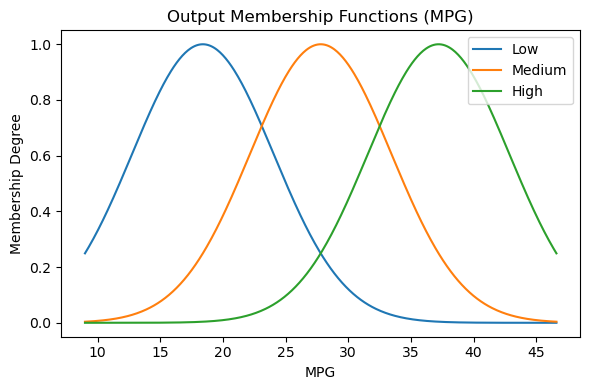

In [109]:
import numpy as np

# Define the output domain (MPG) using training targets only
mpg_min, mpg_max = y_train.min(), y_train.max()
domain_mpg = np.linspace(mpg_min, mpg_max, 500)

# # Output (MPG) membership functions: Low / Medium / High
# mpg_low = trapezoidal_membership_function(
#     domain_mpg,
#     a=mpg_min,
#     b=mpg_min,
#     c=mpg_min + 0.30 * (mpg_max - mpg_min),
#     d=mpg_min + 0.50 * (mpg_max - mpg_min)
# )

# mpg_medium = trapezoidal_membership_function(
#     domain_mpg,
#     a=mpg_min + 0.30 * (mpg_max - mpg_min),
#     b=mpg_min + 0.45 * (mpg_max - mpg_min),
#     c=mpg_min + 0.55 * (mpg_max - mpg_min),
#     d=mpg_min + 0.70 * (mpg_max - mpg_min)
# )

# mpg_high = trapezoidal_membership_function(
#     domain_mpg,
#     a=mpg_min + 0.50 * (mpg_max - mpg_min),
#     b=mpg_min + 0.70 * (mpg_max - mpg_min),
#     c=mpg_max,
#     d=mpg_max
# )

mpg_range = mpg_max - mpg_min
mpg_low = gauss_membership_func(
    domain_mpg,
    c=mpg_min + 0.25 * mpg_range,
    sigma=0.15 * mpg_range
)

mpg_medium = gauss_membership_func(
    domain_mpg,
    c=mpg_min + 0.50 * mpg_range,
    sigma=0.15 * mpg_range
)

mpg_high = gauss_membership_func(
    domain_mpg,
    c=mpg_min + 0.75 * mpg_range,
    sigma=0.15 * mpg_range
)


import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

# Plot output membership functions
plt.plot(domain_mpg, mpg_low, label='Low')
plt.plot(domain_mpg, mpg_medium, label='Medium')
plt.plot(domain_mpg, mpg_high, label='High')

plt.title("Output Membership Functions (MPG)")
plt.xlabel("MPG")
plt.ylabel("Membership Degree")
plt.legend()
plt.tight_layout()
plt.show()


### Rules ###
- R1: IF horsepower is low AND displacement is small
THEN MPG is high

- R2: IF horsepower is medium AND displacement is medium
THEN MPG is medium

- R3: IF horsepower is high AND displacement is large
THEN MPG is low

This function do 2 things:
1. fuzzification. Convert the real data values into the membership value of each fuzzy set.
2. Firing the rules. Use the min membership value of the antecedent clauses to chop off the consequent membership function.
3. Aggregation: The chopoff result are aggregated(We can choose Max aggregation or summation aggregation). 

In [110]:
def mpg_rule_inference(horsepower_value, displacement_value, aggregation="max"):
    """
    Fuzzy rule inference for one Auto MPG sample.
    """

    # -------------------
    # Fuzzification
    # -------------------
    hp_low_firing  = interp_membership(domain_horsepower, hp_low,  horsepower_value)
    hp_med_firing  = interp_membership(domain_horsepower, hp_medium, horsepower_value)
    hp_high_firing = interp_membership(domain_horsepower, hp_high, horsepower_value)

    disp_small_firing  = interp_membership(domain_displacement, disp_small,  displacement_value)
    disp_medium_firing = interp_membership(domain_displacement, disp_medium, displacement_value)
    disp_large_firing  = interp_membership(domain_displacement, disp_large,  displacement_value)

    # -------------------
    # Rule firing (AND = min)
    # -------------------
    # R1: IF horsepower is low AND displacement is small THEN MPG is high
    rule1_activation = min(hp_low_firing, disp_small_firing)

    # R2: IF horsepower is medium AND displacement is medium THEN MPG is medium
    rule2_activation = min(hp_med_firing, disp_medium_firing)

    # R3: IF horsepower is high AND displacement is large THEN MPG is low
    rule3_activation = min(hp_high_firing, disp_large_firing)

    # -------------------
    # Implication (clipping)
    # -------------------
    chopoff1 = np.minimum(mpg_high,   rule1_activation)
    chopoff2 = np.minimum(mpg_medium, rule2_activation)
    chopoff3 = np.minimum(mpg_low,    rule3_activation)

    # -------------------
    # Aggregation
    # -------------------
    if aggregation == "max":
        aggregated_output = np.maximum.reduce([
            chopoff1, chopoff2, chopoff3
        ])
    elif aggregation == "sum":
        aggregated_output = np.sum([
            chopoff1, chopoff2, chopoff3
        ], axis=0)
    else:
        raise ValueError("aggregation must be 'max' or 'sum'")

    return aggregated_output, (rule1_activation, rule2_activation, rule3_activation)


### Deffuzification ###
- The input of this function is the 2 values: horsepower and displacement
- The output value is the prediction.

In [111]:
def mpg_regress(horsepower_value, displacement_value, aggregation="max"):
    """
    Fuzzy regression for one Auto MPG sample.
    Returns a crisp MPG value.
    """

    # Rule inference (same structure as iris_rule_inference)
    aggregated_output, (r1_activation, r2_activation, r3_activation) = mpg_rule_inference(
        horsepower_value, displacement_value, aggregation
    )

    # Defuzzification (centroid)
    crisp_mpg = centroid_defuzzification(domain_mpg, aggregated_output)

    return crisp_mpg, (r1_activation, r2_activation, r3_activation)


In [112]:
# Select representative real samples from the training set

# Combine features and labels for convenience
train_data = X_train.copy()
train_data['mpg'] = y_train

# Sort by MPG
train_sorted = train_data.sort_values('mpg')

# Pick real samples
sample_low  = train_sorted.iloc[0]                  # lowest MPG
sample_mid  = train_sorted.iloc[len(train_sorted)//2]  # median MPG
sample_high = train_sorted.iloc[-1]                 # highest MPG

samples = [
    ("Low MPG sample",  sample_low),
    ("Mid MPG sample",  sample_mid),
    ("High MPG sample", sample_high)
]

for name, sample in samples:
    hp   = float(sample['horsepower'])
    disp = float(sample['displacement'])
    true_mpg = float(sample['mpg'])

    pred_mpg, rules = mpg_regress(hp, disp)

    print(f"\n{name}")
    print(f"Input (horsepower={hp}, displacement={disp})")
    print(f"True MPG: {true_mpg}")
    print(f"Predicted MPG: {pred_mpg}")
    print(f"Rule firing [R1, R2, R3]: {rules}")




Low MPG sample
Input (horsepower=193.0, displacement=304.0)
True MPG: 9.0
Predicted MPG: 20.586992246786572
Rule firing [R1, R2, R3]: (0.0007467553272505709, 0.10390616712509695, 0.6380088206978746)

Mid MPG sample
Input (horsepower=83.0, displacement=140.0)
True MPG: 23.0
Predicted MPG: 35.32838542933604
Rule firing [R1, R2, R3]: (0.9018385340385722, 0.105429942325123, 0.0007664216143001936)

High MPG sample
Input (horsepower=65.0, displacement=86.0)
True MPG: 46.6
Predicted MPG: 35.935956752280305
Rule firing [R1, R2, R3]: (0.3807956556225877, 0.009369726357978869, 1.4336037337887298e-05)


In [113]:
def mpg_rule_inference_weighted(hp_value, disp_value, weights, aggregation="max"):
    """
    Weighted fuzzy rule inference for Auto MPG.
    weights = [w1, w2, w3]
    """

    # -------------------
    # Fuzzification
    # -------------------
    hp_low_firing  = interp_membership(domain_horsepower, hp_low,  hp_value)
    hp_med_firing  = interp_membership(domain_horsepower, hp_medium, hp_value)
    hp_high_firing = interp_membership(domain_horsepower, hp_high, hp_value)

    disp_small_firing  = interp_membership(domain_displacement, disp_small,  disp_value)
    disp_medium_firing = interp_membership(domain_displacement, disp_medium, disp_value)
    disp_large_firing  = interp_membership(domain_displacement, disp_large,  disp_value)

    # -------------------
    # Rule firing (with weights)
    # -------------------
    r1 = weights[0] * min(hp_low_firing,  disp_small_firing)
    r2 = weights[1] * min(hp_med_firing,  disp_medium_firing)
    r3 = weights[2] * min(hp_high_firing, disp_large_firing)

    # -------------------
    # Implication (clipping)
    # -------------------
    chop1 = np.minimum(mpg_high,   r1)
    chop2 = np.minimum(mpg_medium, r2)
    chop3 = np.minimum(mpg_low,    r3)

    # -------------------
    # Aggregation
    # -------------------
    if aggregation == "max":
        aggregated = np.maximum.reduce([chop1, chop2, chop3])
    elif aggregation == "sum":
        aggregated = chop1 + chop2 + chop3
    else:
        raise ValueError("aggregation must be 'max' or 'sum'")

    return aggregated



In [114]:
import numpy as np

def fitness_func(ga_instance, solution, solution_idx):
    """
    solution = [w1, w2, w3]
    fitness = -RMSE on validation set
    """

    weights = solution
    preds = []

    for _, row in X_val.iterrows():
        hp = row['horsepower']
        disp = row['displacement']

        aggregated = mpg_rule_inference_weighted(
            hp, disp, weights
        )

        pred = centroid_defuzzification(domain_mpg, aggregated)
        preds.append(pred)

    preds = np.array(preds)
    true = y_val.values

    rmse = np.sqrt(np.mean((preds - true) ** 2))

    return -rmse   # pygad maximizes fitness



In [115]:
import pygad

ga_instance = pygad.GA(
    num_generations=40,
    num_parents_mating=8,
    fitness_func=fitness_func,
    sol_per_pop=20,
    num_genes=3,
    gene_space=[
        (0.0, 1.5),
        (0.0, 1.5),
        (0.0, 1.5)
    ],
    parent_selection_type="sss",
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=30,
    random_seed=42
)



e:\Anaconda3install\envs\fuzzyEnv\lib\site-packages\pygad\pygad.py:753: UserWarning: The percentage of genes to mutate (mutation_percent_genes=30) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(f"The percentage of genes to mutate (mutation_percent_genes={mutation_percent_genes}) resulted in selecting ({mutation_num_genes}) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).\nIf you do not want to mutate any gene, please set mutation_type=None.")


In [116]:
ga_instance.run()


In [117]:
solution, solution_fitness, _ = ga_instance.best_solution()

print("Best rule weights [w1, w2, w3]:", solution)
print("Best validation RMSE:", -solution_fitness)


Best rule weights [w1, w2, w3]: [0.  0.  1.5]
Best validation RMSE: 4.961671828355194


In [118]:
# Select representative real samples from the training set

# Combine features and labels for convenience
train_data = X_train.copy()
train_data['mpg'] = y_train

# Sort by MPG
train_sorted = train_data.sort_values('mpg')

# Pick real samples
sample_low  = train_sorted.iloc[0]                     # lowest MPG
sample_mid  = train_sorted.iloc[len(train_sorted)//2]  # median MPG
sample_high = train_sorted.iloc[-1]                    # highest MPG

samples = [
    ("Low MPG sample",  sample_low),
    ("Mid MPG sample",  sample_mid),
    ("High MPG sample", sample_high)
]

# Use GA-optimized rule weights
weights = solution   # [w1, w2, w3]

for name, sample in samples:
    hp   = float(sample['horsepower'])
    disp = float(sample['displacement'])
    true_mpg = float(sample['mpg'])

    # --- NEW: weighted fuzzy inference ---
    aggregated = mpg_rule_inference_weighted(
        hp, disp, weights
    )
    pred_mpg = centroid_defuzzification(domain_mpg, aggregated)

    print(f"\n{name}")
    print(f"Input (horsepower={hp}, displacement={disp})")
    print(f"True MPG: {true_mpg}")
    print(f"Predicted MPG (GA-weighted): {pred_mpg}")



Low MPG sample
Input (horsepower=193.0, displacement=304.0)
True MPG: 9.0
Predicted MPG (GA-weighted): 18.986408386061946

Mid MPG sample
Input (horsepower=83.0, displacement=140.0)
True MPG: 23.0
Predicted MPG (GA-weighted): 24.802631116248733

High MPG sample
Input (horsepower=65.0, displacement=86.0)
True MPG: 46.6
Predicted MPG (GA-weighted): 27.254449080273485


In [119]:
import numpy as np

# --- Baseline fuzzy prediction on test set ---
y_pred_test = []
rule_firing_test = []

for _, row in X_test.iterrows():
    hp = float(row["horsepower"])
    disp = float(row["displacement"])
    
    pred_mpg, rules = mpg_regress(hp, disp)  # your unweighted regression function
    y_pred_test.append(pred_mpg)
    rule_firing_test.append(rules)

y_pred_test = np.array(y_pred_test, dtype=float)
y_true_test = y_test.values.astype(float)

# --- Metrics ---
test_mae = np.mean(np.abs(y_pred_test - y_true_test))
test_rmse = np.sqrt(np.mean((y_pred_test - y_true_test) ** 2))

print("Baseline Fuzzy (Test Set)")
print(f"MAE  = {test_mae:.4f}")
print(f"RMSE = {test_rmse:.4f}")


Baseline Fuzzy (Test Set)
MAE  = 9.4943
RMSE = 10.3196


In [120]:
import numpy as np

# --- GA-weighted fuzzy prediction on test set ---
weights = solution  # best weights from GA, e.g., [w1, w2, w3]

y_pred_test_ga = []

for _, row in X_test.iterrows():
    hp = float(row["horsepower"])
    disp = float(row["displacement"])
    
    aggregated = mpg_rule_inference_weighted(hp, disp, weights, aggregation="max")
    pred_mpg = centroid_defuzzification(domain_mpg, aggregated)
    y_pred_test_ga.append(pred_mpg)

y_pred_test_ga = np.array(y_pred_test_ga, dtype=float)
y_true_test = y_test.values.astype(float)

# --- Metrics ---
test_mae_ga = np.mean(np.abs(y_pred_test_ga - y_true_test))
test_rmse_ga = np.sqrt(np.mean((y_pred_test_ga - y_true_test) ** 2))

print("GA-Weighted Fuzzy (Test Set)")
print("Weights [w1, w2, w3]:", weights)
print(f"MAE  = {test_mae_ga:.4f}")
print(f"RMSE = {test_rmse_ga:.4f}")


GA-Weighted Fuzzy (Test Set)
Weights [w1, w2, w3]: [0.  0.  1.5]
MAE  = 4.1257
RMSE = 5.1507


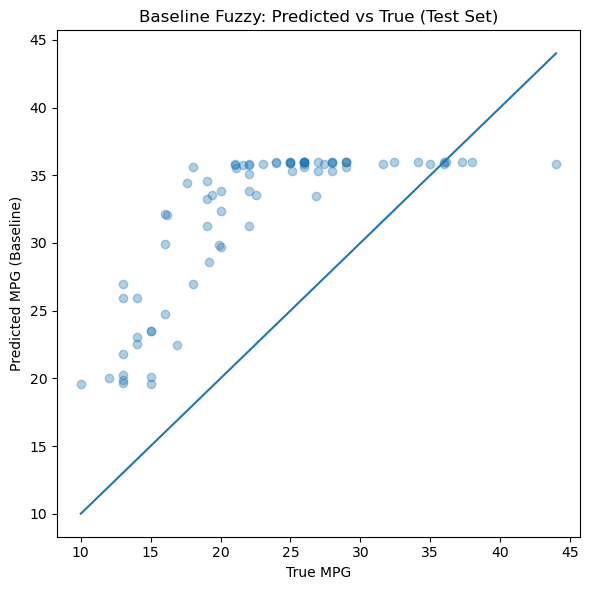

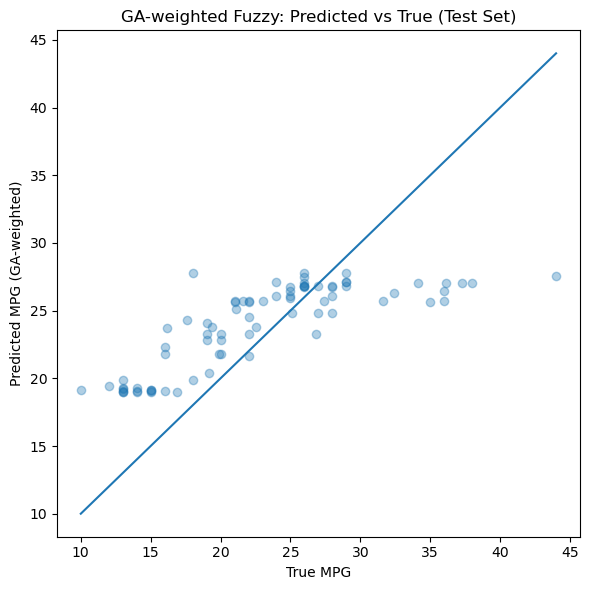

In [121]:
import matplotlib.pyplot as plt

# --- Plot: Baseline ---
plt.figure(figsize=(6, 6))
plt.scatter(y_true_test, y_pred_test, alpha=0.35)
minv = min(y_true_test.min(), y_pred_test.min())
maxv = max(y_true_test.max(), y_pred_test.max())
plt.plot([minv, maxv], [minv, maxv])
plt.xlabel("True MPG")
plt.ylabel("Predicted MPG (Baseline)")
plt.title("Baseline Fuzzy: Predicted vs True (Test Set)")
plt.tight_layout()
plt.show()

# --- Plot: GA-weighted (only if you computed y_pred_test_ga) ---
plt.figure(figsize=(6, 6))
plt.scatter(y_true_test, y_pred_test_ga, alpha=0.35)
minv = min(y_true_test.min(), y_pred_test_ga.min())
maxv = max(y_true_test.max(), y_pred_test_ga.max())
plt.plot([minv, maxv], [minv, maxv])
plt.xlabel("True MPG")
plt.ylabel("Predicted MPG (GA-weighted)")
plt.title("GA-weighted Fuzzy: Predicted vs True (Test Set)")
plt.tight_layout()
plt.show()


In [122]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Sample a few rows from the test set
idx = np.random.choice(len(X_test), size=min(10, len(X_test)), replace=False)
X_sample = X_test.iloc[idx].copy()
y_sample = y_test.iloc[idx].copy()

rows = []
for i in range(len(X_sample)):
    hp = float(X_sample.iloc[i]["horsepower"])
    disp = float(X_sample.iloc[i]["displacement"])
    true_mpg = float(y_sample.iloc[i])

    pred_base, _ = mpg_regress(hp, disp)

    aggregated = mpg_rule_inference_weighted(hp, disp, solution, aggregation="max")
    pred_ga = centroid_defuzzification(domain_mpg, aggregated)

    rows.append([hp, disp, true_mpg, pred_base, pred_ga])

df_compare = pd.DataFrame(
    rows, columns=["horsepower", "displacement", "true_mpg", "pred_baseline", "pred_ga"]
)

print(df_compare)


   horsepower  displacement  true_mpg  pred_baseline    pred_ga
0       145.0         350.0      15.0      23.491622  19.136199
1        69.0          96.0      26.0      36.000797  26.833143
2        68.0          91.0      34.1      35.979440  27.049073
3        90.0         232.0      19.4      33.556861  23.807724
4        80.0         121.0      27.4      35.809973  25.690027
5        46.0          97.0      26.0      35.612377  27.753059
6       190.0         390.0      15.0      20.115504  18.982252
7        72.0         140.0      22.0      35.788315  25.633905
8        86.0         140.0      27.0      35.328385  24.802631
9       155.0         350.0      16.9      22.433355  18.989648
